In [ ]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_7.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5";
data_arrays = reader.fetch_phi2D_data(directory_path);

Found 4001 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Compiled data from 3000 files...
Compiled data from 4000 files...
Finished compiling data from all files in the directory.


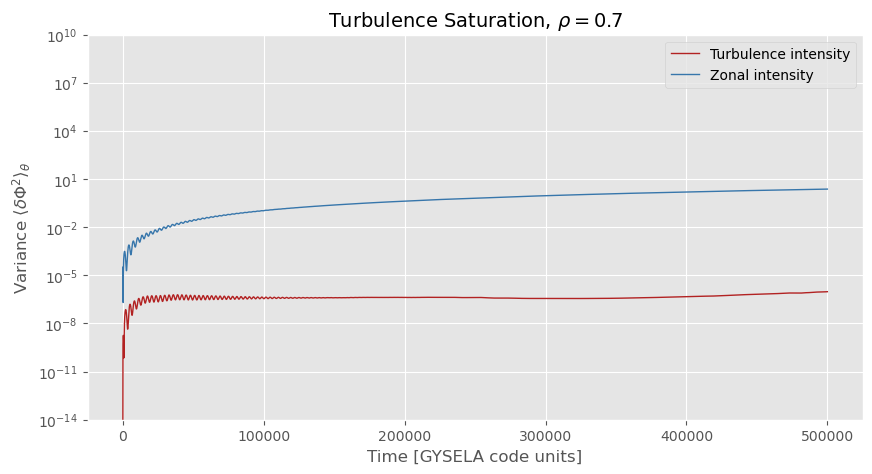

In [ ]:
def generate_turbulent_variance_time_series(phi2D_list, effective_radius = None):

	# Cull zonal component to extract turbulence intensity.
	operation = lambda entry: ((entry - entry.mean(dim="theta")) ** 2).mean(dim="theta");
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	variance_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		variance_series = gys_utils.slice_at_effective_radius(variance_series, effective_radius);

	return variance_series;

def generate_zonal_time_series(phi2D_list, effective_radius = None):

	# Take a simple poloidal average and square to isolate zonal mode intensities.
	operation = lambda entry: entry.mean(dim = "theta") ** 2;
	radial_strips = [operation(phi2D_xarray) for phi2D_xarray in phi2D_list];
	zonal_series = xr.concat(radial_strips, dim = "time");

	if not effective_radius is None:
		zonal_series = gys_utils.slice_at_effective_radius(zonal_series, effective_radius);

	return zonal_series;

def plot_turbulence_saturation(phi2D_list, dt_diag, effective_radius, log_scale = False):

	variance_series = generate_turbulent_variance_time_series(phi2D_list, effective_radius);
	zonal_series = generate_zonal_time_series(phi2D_list, effective_radius);
	time_range = np.arange(len(variance_series)) * dt_diag;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	operation = plt.semilogy if log_scale else plt.plot;
	operation(time_range, variance_series, color = "firebrick", lw = 1.0, label = "Turbulence intensity");
	operation(time_range, zonal_series, color = "#3776ab", lw = 1.0, label = "Zonal intensity");
	plt.title(f"Turbulence Saturation, $\\rho = {effective_radius}$", fontsize = 14);
	plt.xlabel("Time [GYSELA code units]", fontsize = 12);
	plt.ylabel(r"Variance $\langle \delta \Phi^2 \rangle_\theta$", fontsize = 12);
	plt.ylim(10e-15, 10e9);
	plt.legend();
	plt.show();

plot_turbulence_saturation(data_arrays, dt_diag = 125, effective_radius = 0.7, log_scale = True);